# Recommendation System Project: IBM Community Articles

This notebook builds and evaluates four complementary recommendation strategies for
implicit-feedback data from the IBM Watson Studio Community. The implementation is
deterministic, rubric-aligned, and designed to run from a fresh kernel.

## Objectives and success criteria

- reproduce every required exploratory statistic and supplied test contract;
- recommend popular articles for users with no history;
- recommend unseen articles through user-user collaborative filtering;
- group semantically related titles with TF-IDF, LSA, and KMeans;
- expose `U`, `Sigma`, and `V-transpose` representations and use 200 latent features
  for article similarity;
- discuss honest offline and online evaluation beyond in-sample reconstruction.

## Contents

1. Exploratory Data Analysis
2. Rank-Based Recommendations
3. User-User Collaborative Filtering
4. Content-Based Recommendations
5. Matrix Factorization
6. Deployment-Ready Facade and Final Validation


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer

import project_tests as t

RANDOM_STATE = 42
DATA_PATH = Path("data/user-item-interactions.csv")
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_colwidth", 90)
plt.style.use("seaborn-v0_8-whitegrid")

df = pd.read_csv(
    DATA_PATH,
    index_col=0,
    dtype={"article_id": "int64", "title": "string", "email": "string"},
)
print(f"Loaded {df.shape[0]:,} interactions and {df.shape[1]} source features.")
schema_summary = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "non_null_rows": df.notna().sum(),
        "missing_rows": df.isna().sum(),
    }
)
display(schema_summary)


Loaded 45,993 interactions and 3 source features.


,dtype,non_null_rows,missing_rows
article_id,int64,45993,0
title,string,45993,0
email,string,45976,17


## Part I: Exploratory Data Analysis

The source contains implicit interactions rather than ratings. Repeated rows therefore
count as repeated views for popularity analysis. Missing e-mail hashes are mapped to one
`unknown_user`, matching the supplied evaluation contract.


In [2]:
missing_email_count = int(df["email"].isna().sum())
print(f"Missing e-mail identifiers before cleaning: {missing_email_count}")
display(df.isna().sum().rename("missing_rows").to_frame())

df["email"] = df["email"].fillna("unknown_user")
assert missing_email_count == 17
assert not df["email"].isna().any()
print("Missing identifiers mapped to one unknown_user: PASS")


Missing e-mail identifiers before cleaning: 17


,missing_rows
article_id,0
title,0
email,17


Missing identifiers mapped to one unknown_user: PASS


In [3]:
interactions_per_user = df.groupby("email", sort=False).size()
views_per_article = df.groupby("article_id", sort=False).size()

user_summary = interactions_per_user.describe().rename("interactions_per_user").to_frame()
article_summary = views_per_article.describe().rename("views_per_article").to_frame()
display(user_summary.round(2).join(article_summary.round(2), how="outer"))


,interactions_per_user,views_per_article
25%,1.00,8.00
50%,3.00,25.00
75%,9.00,69.00
count,5149.00,714.00
max,364.00,937.00
mean,8.93,64.42
min,1.00,1.00
std,16.80,109.18


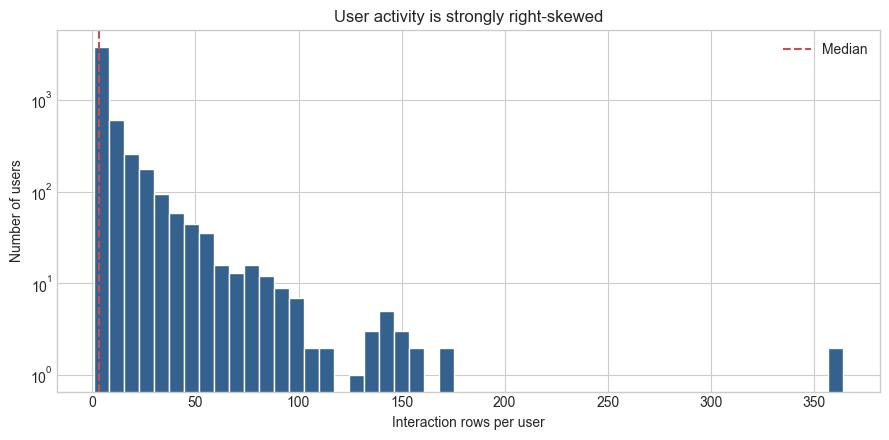

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(interactions_per_user, bins=50, color="#35618f", edgecolor="white")
ax.axvline(interactions_per_user.median(), color="#c44e52", linestyle="--", label="Median")
ax.set(
    xlabel="Interaction rows per user",
    ylabel="Number of users",
    title="User activity is strongly right-skewed",
)
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.show()


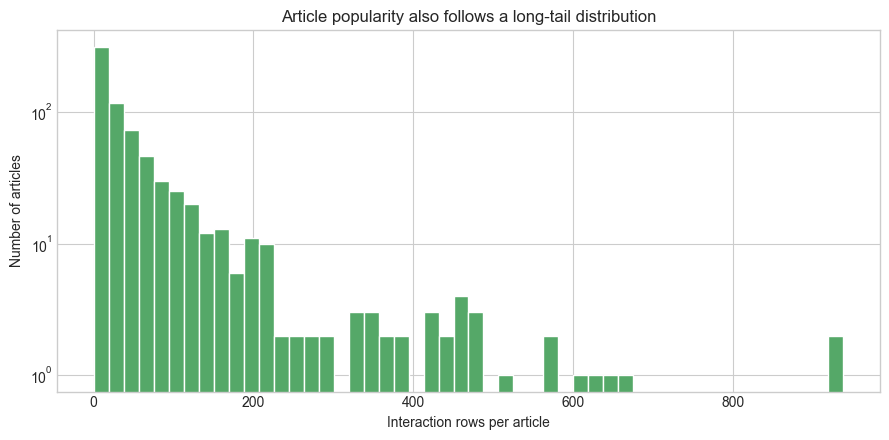

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(views_per_article, bins=50, color="#55a868", edgecolor="white")
ax.set(
    xlabel="Interaction rows per article",
    ylabel="Number of articles",
    title="Article popularity also follows a long-tail distribution",
)
ax.set_yscale("log")
plt.tight_layout()
plt.show()


In [6]:
median_val = int(interactions_per_user.median())
max_views_by_user = int(interactions_per_user.max())
unique_articles = int(df["article_id"].nunique())
total_articles = int(df["article_id"].nunique())
unique_users = int(df["email"].nunique())
user_article_interactions = int(len(df))

article_view_ranking = (
    df.groupby("article_id", as_index=False)
    .size()
    .rename(columns={"size": "interaction_count"})
    .sort_values(
        ["interaction_count", "article_id"],
        ascending=[False, True],
        kind="mergesort",
        ignore_index=True,
    )
)
most_viewed_article_id = int(article_view_ranking.loc[0, "article_id"])
max_views = int(article_view_ranking.loc[0, "interaction_count"])

part_i_metrics = pd.Series(
    {
        "median interactions per user": median_val,
        "interaction rows": user_article_interactions,
        "maximum interactions by one user": max_views_by_user,
        "most-viewed article count": max_views,
        "most-viewed article ID": most_viewed_article_id,
        "interacted articles": unique_articles,
        "modeled users": unique_users,
        "catalog articles in this snapshot": total_articles,
    },
    name="value",
)
display(part_i_metrics.to_frame())


,value
median interactions per user,3
interaction rows,45993
maximum interactions by one user,364
most-viewed article count,937
most-viewed article ID,1429
interacted articles,714
modeled users,5149
catalog articles in this snapshot,714


In [7]:
def email_mapper(interactions=df):
    """Map user hashes to sequential integer IDs in first-appearance order."""
    coded_users = {
        email: user_id
        for user_id, email in enumerate(interactions["email"].unique(), start=1)
    }
    return interactions["email"].map(coded_users).astype(int).tolist()


df["user_id"] = email_mapper(df)
df = df.drop(columns="email")
print(f"Mapped interactions to {df['user_id'].nunique():,} sequential user IDs.")
display(df.dtypes.astype(str).rename("dtype").to_frame())


Mapped interactions to 5,149 sequential user IDs.


,dtype
article_id,int64
title,string
user_id,int64


In [8]:
sol_1_dict = {
    "`50% of individuals have _____ or fewer interactions.`": median_val,
    "`The total number of user-article interactions in the dataset is ______.`": user_article_interactions,
    "`The maximum number of user-article interactions by any 1 user is ______.`": max_views_by_user,
    "`The most viewed article in the dataset was viewed _____ times.`": max_views,
    "`The article_id of the most viewed article is ______.`": most_viewed_article_id,
    "`The number of unique articles that have at least 1 rating ______.`": unique_articles,
    "`The number of unique users in the dataset is ______`": unique_users,
    "`The number of unique articles on the IBM platform`": total_articles,
}
expected_sol_1 = {
    "`50% of individuals have _____ or fewer interactions.`": 3,
    "`The total number of user-article interactions in the dataset is ______.`": 45993,
    "`The maximum number of user-article interactions by any 1 user is ______.`": 364,
    "`The most viewed article in the dataset was viewed _____ times.`": 937,
    "`The article_id of the most viewed article is ______.`": 1429,
    "`The number of unique articles that have at least 1 rating ______.`": 714,
    "`The number of unique users in the dataset is ______`": 5149,
    "`The number of unique articles on the IBM platform`": 714,
}
assert sol_1_dict == expected_sol_1
t.sol_1_test(sol_1_dict)
print("Explicit Part I assertion: PASS")


It looks like you have everything right here! Nice job!
Explicit Part I assertion: PASS


**Interpretation.** Half of the modeled users have only three interaction rows, whereas
the most active user has 364. Article views are similarly concentrated: the leading
article has 937 views. This long-tail behavior supports popularity as a cold-start
baseline, but also motivates personalized methods so less-popular relevant content can
surface. In this supplied snapshot, all 714 catalog articles have at least one interaction,
so `unique_articles` and `total_articles` are equal.


## Part II: Rank-Based Recommendations

With no explicit ratings, the rank baseline orders articles by raw interaction rows.
Article ID is the deterministic secondary key.


In [9]:
def _validate_recommendation_count(n):
    """Validate a requested recommendation count and return it as a Python integer."""
    if isinstance(n, bool) or not isinstance(n, (int, np.integer)):
        raise TypeError("The recommendation count must be an integer.")
    if n < 0:
        raise ValueError("The recommendation count cannot be negative.")
    return int(n)


def _rank_articles_by_interactions(interactions):
    """Return one row per article ordered by raw interaction count and article ID."""
    return (
        interactions.groupby(["article_id", "title"], as_index=False)
        .size()
        .rename(columns={"size": "interaction_count"})
        .sort_values(
            ["interaction_count", "article_id"],
            ascending=[False, True],
            kind="mergesort",
            ignore_index=True,
        )
    )


def get_top_articles(n, df=df):
    """Return the titles of the `n` articles with the most interaction rows."""
    limit = _validate_recommendation_count(n)
    return _rank_articles_by_interactions(df).head(limit)["title"].astype(str).tolist()


def get_top_article_ids(n, df=df):
    """Return integer IDs of the `n` articles with the most interaction rows."""
    limit = _validate_recommendation_count(n)
    return [
        int(article_id)
        for article_id in _rank_articles_by_interactions(df).head(limit)["article_id"]
    ]


In [10]:
expected_top_10_ids = [1429, 1330, 1431, 1427, 1364, 1314, 1293, 1170, 1162, 1304]
assert get_top_article_ids(10) == expected_top_10_ids
assert get_top_article_ids(0) == []
assert len(get_top_articles(10)) == 10

print("Top 10 article IDs:", get_top_article_ids(10))
display(pd.DataFrame({"article_id": get_top_article_ids(10), "title": get_top_articles(10)}))
t.sol_2_test(get_top_articles)
print("Explicit ordered rank assertions: PASS")


Top 10 article IDs: [1429, 1330, 1431, 1427, 1364, 1314, 1293, 1170, 1162, 1304]


,article_id,title
0,1429,use deep learning for image classification
1,1330,insights from new york car accident reports
2,1431,visualize car data with brunel
3,1427,"use xgboost, scikit-learn & ibm watson machine learning apis"
4,1364,predicting churn with the spss random tree algorithm
5,1314,healthcare python streaming application demo
6,1293,finding optimal locations of new store using decision optimization
7,1170,"apache spark lab, part 1: basic concepts"
8,1162,analyze energy consumption in buildings
9,1304,gosales transactions for logistic regression model


Your top_5 looks like the solution list! Nice job.
Your top_10 looks like the solution list! Nice job.
Your top_20 looks like the solution list! Nice job.
Explicit ordered rank assertions: PASS


## Part III: User-User Collaborative Filtering

Repeated views are collapsed to a binary user-item matrix. Cosine similarity normalizes
for different user activity levels and matches the supplied neighbor contracts. The
improved recommender then prioritizes more-active neighbors when similarities tie and
orders each neighbor's unseen candidates by global interaction popularity.


In [11]:
def create_user_item_matrix(df, fill_value=0):
    """Create a binary user-by-article DataFrame from interaction records.

    `fill_value` is retained for compatibility with the project template; absent
    interactions are always represented by zero and observed interactions by one.
    """
    if fill_value != 0:
        raise ValueError("A binary implicit-feedback matrix requires fill_value=0.")
    interaction_counts = pd.crosstab(df["user_id"], df["article_id"])
    user_item_matrix = interaction_counts.gt(0).astype("int8")
    user_item_matrix.index = user_item_matrix.index.astype(int)
    user_item_matrix.columns = user_item_matrix.columns.astype(int)
    return user_item_matrix.sort_index().sort_index(axis=1)


user_item = create_user_item_matrix(df)
matrix_density = float(user_item.to_numpy().mean())

assert user_item.shape == (5149, 714)
assert int(user_item.sum(axis=1).loc[1]) == 36
assert set(np.unique(user_item.to_numpy())) == {0, 1}
print(f"User-item shape: {user_item.shape}; density: {matrix_density:.4%}")
print("User-item matrix tests: PASS")


User-item shape: (5149, 714); density: 0.9162%
User-item matrix tests: PASS


In [12]:
def find_similar_users(user_id, user_item=user_item, include_similarity=False):
    """Return all other users ordered by cosine similarity to `user_id`.

    When `include_similarity` is true, each result is `[neighbor_id, similarity]`.
    Residual similarity ties are resolved by ascending neighbor ID for reproducibility.
    """
    if user_id not in user_item.index:
        raise KeyError(f"User {user_id} is not present in the user-item matrix.")

    similarities = cosine_similarity(user_item.loc[[user_id]], user_item).ravel()
    neighbors = pd.DataFrame(
        {"neighbor_id": user_item.index.to_numpy(), "similarity": similarities}
    )
    neighbors = (
        neighbors.loc[neighbors["neighbor_id"] != user_id]
        .sort_values(
            ["similarity", "neighbor_id"],
            ascending=[False, True],
            kind="mergesort",
            ignore_index=True,
        )
    )
    if include_similarity:
        return [
            [int(row.neighbor_id), float(row.similarity)]
            for row in neighbors.itertuples(index=False)
        ]
    return neighbors["neighbor_id"].astype(int).tolist()


print("Ten users most similar to user 1:", find_similar_users(1)[:10])
assert find_similar_users(1)[0] == 3933


Ten users most similar to user 1: [3933, 46, 4201, 253, 824, 5034, 5041, 136, 2305, 395]


In [13]:
def get_article_names(article_ids, df=df):
    """Return one article title per supplied ID while preserving input order."""
    article_ids = [int(article_id) for article_id in article_ids]
    title_map = (
        df[["article_id", "title"]]
        .drop_duplicates("article_id")
        .set_index("article_id")["title"]
        .astype(str)
        .to_dict()
    )
    unknown = [article_id for article_id in article_ids if article_id not in title_map]
    if unknown:
        raise KeyError(f"Unknown article IDs: {unknown}")
    return [title_map[article_id] for article_id in article_ids]


def get_ranked_article_unique_counts(article_ids, user_item=user_item):
    """Rank supplied article IDs by unique interacting users, then by article ID."""
    candidate_ids = list(dict.fromkeys(int(article_id) for article_id in article_ids))
    unknown = [article_id for article_id in candidate_ids if article_id not in user_item.columns]
    if unknown:
        raise KeyError(f"Unknown article IDs: {unknown}")
    if not candidate_ids:
        return []
    counts = user_item[candidate_ids].sum(axis=0).rename("unique_user_count")
    ranked = (
        counts.rename_axis("article_id")
        .reset_index()
        .sort_values(
            ["unique_user_count", "article_id"],
            ascending=[False, True],
            kind="mergesort",
        )
    )
    return [
        [int(row.article_id), int(row.unique_user_count)]
        for row in ranked.itertuples(index=False)
    ]


def get_user_articles(user_id, user_item=user_item):
    """Return IDs and titles of all articles previously observed for a user."""
    if user_id not in user_item.index:
        raise KeyError(f"User {user_id} is not present in the user-item matrix.")
    article_ids = [
        int(article_id)
        for article_id in user_item.columns[user_item.loc[user_id].to_numpy() == 1]
    ]
    return article_ids, get_article_names(article_ids)


def user_user_recs(user_id, m=10, user_item=user_item, df=df):
    """Return up to `m` unseen articles from cosine-nearest users.

    Unknown users and any unfilled slots fall back to global popularity.
    This baseline does not use neighbor-activity tie-breaking.
    """
    limit = _validate_recommendation_count(m)
    if limit == 0:
        return []
    if user_id not in user_item.index:
        return get_top_article_ids(limit, df)

    seen = set(get_user_articles(user_id, user_item)[0])
    recommendations = []
    recommended = set()
    for neighbor_id in find_similar_users(user_id, user_item):
        for article_id in get_user_articles(neighbor_id, user_item)[0]:
            if article_id not in seen and article_id not in recommended:
                recommendations.append(int(article_id))
                recommended.add(int(article_id))
                if len(recommendations) == limit:
                    return recommendations

    for article_id in get_top_article_ids(len(user_item.columns), df):
        if article_id not in seen and article_id not in recommended:
            recommendations.append(article_id)
            recommended.add(article_id)
            if len(recommendations) == limit:
                break
    return recommendations


In [14]:
expected_titles = {
    "using deep learning to reconstruct high-resolution audio",
    "build a python app on the streaming analytics service",
    "gosales transactions for naive bayes model",
    "healthcare python streaming application demo",
    "use r dataframes & ibm watson natural language understanding",
    "use xgboost, scikit-learn & ibm watson machine learning apis",
}
assert set(get_article_names([1024, 1176, 1305, 1314, 1422, 1427])) == expected_titles
assert set(get_user_articles(20)[0]) == {1320, 232, 844}
assert set(get_user_articles(2)[0]) == {1024, 1176, 1305, 1314, 1422, 1427}
assert get_ranked_article_unique_counts([1320, 232, 844])[0] == [1320, 123]

baseline_recs = user_user_recs(1, 10)
assert len(baseline_recs) == len(set(baseline_recs)) == 10
assert not set(baseline_recs).intersection(get_user_articles(1)[0])
print("Collaborative helper and baseline tests: PASS")


Collaborative helper and baseline tests: PASS


In [15]:
def get_top_sorted_users(user_id, user_item=user_item):
    """Return neighbors sorted by cosine similarity, activity, and user ID."""
    if user_id not in user_item.index:
        raise KeyError(f"User {user_id} is not present in the user-item matrix.")
    similarities = cosine_similarity(user_item.loc[[user_id]], user_item).ravel()
    neighbors = pd.DataFrame(
        {
            "neighbor_id": user_item.index.to_numpy(),
            "similarity": similarities,
            "num_interactions": user_item.sum(axis=1).to_numpy(),
        }
    )
    return (
        neighbors.loc[neighbors["neighbor_id"] != user_id]
        .sort_values(
            ["similarity", "num_interactions", "neighbor_id"],
            ascending=[False, False, True],
            kind="mergesort",
            ignore_index=True,
        )
    )


def user_user_recs_part2(user_id, m=10, user_item=user_item, df=df):
    """Return activity-aware user-user recommendations and their titles.

    Neighbors are visited by cosine similarity and activity. Each neighbor's unseen
    candidates are ordered by global raw interaction popularity. Unknown users use the
    popularity fallback directly.
    """
    limit = _validate_recommendation_count(m)
    if limit == 0:
        return [], []
    popularity_order = get_top_article_ids(len(user_item.columns), df)
    if user_id not in user_item.index:
        ids = popularity_order[:limit]
        return ids, get_article_names(ids, df)

    seen = set(get_user_articles(user_id, user_item)[0])
    recommendations = []
    recommended = set()
    for neighbor_id in get_top_sorted_users(user_id, user_item)["neighbor_id"]:
        neighbor_articles = set(get_user_articles(int(neighbor_id), user_item)[0])
        for article_id in popularity_order:
            if (
                article_id in neighbor_articles
                and article_id not in seen
                and article_id not in recommended
            ):
                recommendations.append(article_id)
                recommended.add(article_id)
                if len(recommendations) == limit:
                    return recommendations, get_article_names(recommendations, df)

    for article_id in popularity_order:
        if article_id not in seen and article_id not in recommended:
            recommendations.append(article_id)
            recommended.add(article_id)
            if len(recommendations) == limit:
                break
    return recommendations, get_article_names(recommendations, df)


In [16]:
rec_ids, rec_names = user_user_recs_part2(20, 10)
display(pd.DataFrame({"article_id": rec_ids, "title": rec_names}))

seen_by_20 = set(get_user_articles(20)[0])
assert len(rec_ids) == len(set(rec_ids)) == 10
assert not seen_by_20.intersection(rec_ids)
print("Improved collaborative recommendation constraints: PASS")


,article_id,title
0,1293,finding optimal locations of new store using decision optimization
1,1162,analyze energy consumption in buildings
2,1185,classify tumors with machine learning
3,1165,analyze precipitation data
4,254,"apple, ibm add machine learning to partnership with watson-core ml coupling"
5,1271,customer demographics and sales
6,1328,income (2015): united states demographic measures
7,1410,uci: sms spam collection
8,40,ensemble learning to improve machine learning results
9,1402,uci: adult - predict income


Improved collaborative recommendation constraints: PASS


In [17]:
user1_most_sim = int(get_top_sorted_users(1).iloc[0]["neighbor_id"])
user2_6th_sim = int(get_top_sorted_users(2).iloc[5]["neighbor_id"])
user131_10th_sim = int(get_top_sorted_users(131).iloc[9]["neighbor_id"])

sol_5_dict = {
    "The user that is most similar to user 1.": user1_most_sim,
    "The user that is the 6th most similar to user 2.": user2_6th_sim,
    "The user that is the 10th most similar to user 131.": user131_10th_sim,
}
expected_sol_5 = {
    "The user that is most similar to user 1.": 3933,
    "The user that is the 6th most similar to user 2.": 3586,
    "The user that is the 10th most similar to user 131.": 383,
}
assert sol_5_dict == expected_sol_5
t.sol_5_test(sol_5_dict)
print("Explicit similar-user ordering assertion: PASS")


This all looks good!  Nice job!
Explicit similar-user ordering assertion: PASS


### New users and cold start

A new user has no interaction vector, so neither user-user similarity nor personalized
matrix factorization can identify preferences. The defensible baseline is the rank-based
list because it uses the strongest aggregate signal available. In production, onboarding
topics, geography, referrer context, or a short preference survey could diversify this
fallback. As soon as a few interactions arrive, a hybrid can blend popularity with content
similarity before relying more heavily on collaborative methods.


In [18]:
new_user_recs = get_top_article_ids(10)
assert new_user_recs == expected_top_10_ids
assert set(new_user_recs) == {
    1314, 1429, 1293, 1427, 1162, 1364, 1304, 1170, 1431, 1330
}
print("Cold-start popularity recommendation test: PASS")


Cold-start popularity recommendation test: PASS


## Part IV: Content-Based Recommendations

The only available content is the title. TF-IDF represents discriminative title terms,
50-component latent semantic analysis reduces noise, and normalization makes direction
comparable. KMeans then creates candidate groups. Cluster count is selected from an
explicit grid that includes 50 rather than relying on the scaffold's near-50 value.


In [19]:
df_unique_articles = (
    df[["article_id", "title"]]
    .drop_duplicates("article_id")
    .sort_values("article_id")
    .reset_index(drop=True)
)

vectorizer = TfidfVectorizer(
    max_df=0.75,
    min_df=5,
    stop_words="english",
    max_features=200,
)
X_tfidf = vectorizer.fit_transform(df_unique_articles["title"].astype(str))

lsa = make_pipeline(
    TruncatedSVD(n_components=50, random_state=RANDOM_STATE),
    Normalizer(copy=False),
)
X_lsa = lsa.fit_transform(X_tfidf)
explained_variance = float(lsa[0].explained_variance_ratio_.sum())

print(f"TF-IDF shape: {X_tfidf.shape}")
print(f"LSA shape: {X_lsa.shape}")
print(f"Explained variance from 50 LSA components: {explained_variance:.2%}")


TF-IDF shape: (714, 125)
LSA shape: (714, 50)
Explained variance from 50 LSA components: 76.00%


,n_clusters,inertia,silhouette,min_cluster_size,median_cluster_size,max_cluster_size
0,10,405.488,0.207,22,48.0,304
1,25,262.301,0.362,7,23.0,160
2,50,146.619,0.457,4,10.5,63
3,75,97.517,0.510,1,7.0,50
4,100,79.367,0.522,1,5.0,50
5,150,48.755,0.559,1,3.0,49
6,200,30.580,0.568,1,2.0,49
7,250,16.264,0.583,1,1.0,49


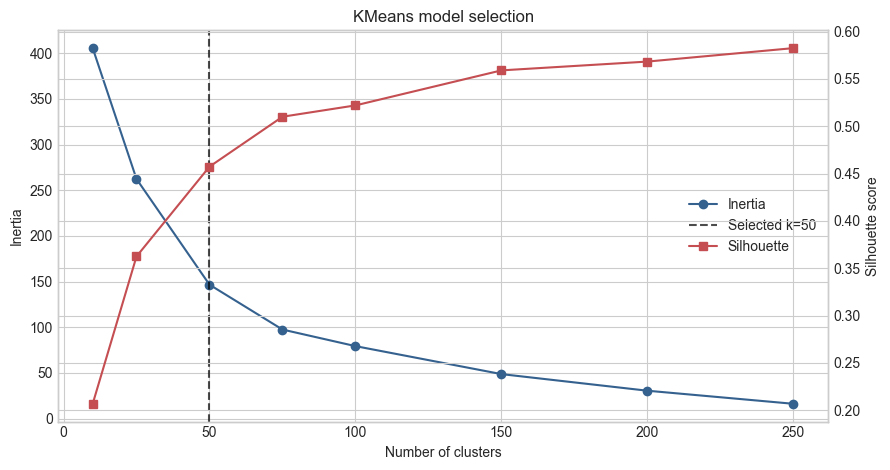

In [20]:
cluster_candidates = [10, 25, 50, 75, 100, 150, 200, 250]
cluster_diagnostics = []
for candidate_k in cluster_candidates:
    candidate_model = KMeans(
        n_clusters=candidate_k,
        max_iter=50,
        n_init=5,
        random_state=RANDOM_STATE,
    ).fit(X_lsa)
    sizes = np.bincount(candidate_model.labels_, minlength=candidate_k)
    cluster_diagnostics.append(
        {
            "n_clusters": candidate_k,
            "inertia": candidate_model.inertia_,
            "silhouette": silhouette_score(X_lsa, candidate_model.labels_),
            "min_cluster_size": int(sizes.min()),
            "median_cluster_size": float(np.median(sizes)),
            "max_cluster_size": int(sizes.max()),
        }
    )

cluster_diagnostics = pd.DataFrame(cluster_diagnostics)
display(cluster_diagnostics.round(3))

fig, inertia_ax = plt.subplots(figsize=(9, 4.8))
silhouette_ax = inertia_ax.twinx()
inertia_ax.plot(
    cluster_diagnostics["n_clusters"],
    cluster_diagnostics["inertia"],
    marker="o",
    color="#35618f",
    label="Inertia",
)
silhouette_ax.plot(
    cluster_diagnostics["n_clusters"],
    cluster_diagnostics["silhouette"],
    marker="s",
    color="#c44e52",
    label="Silhouette",
)
inertia_ax.axvline(50, color="black", linestyle="--", alpha=0.7, label="Selected k=50")
inertia_ax.set(xlabel="Number of clusters", ylabel="Inertia", title="KMeans model selection")
silhouette_ax.set_ylabel("Silhouette score")
lines = inertia_ax.get_lines() + silhouette_ax.get_lines()
inertia_ax.legend(lines, [line.get_label() for line in lines], loc="center right")
plt.tight_layout()
plt.show()


**Cluster selection.** The inertia curve bends sharply by roughly 50 clusters; later gains
require increasingly fragmented groups. Silhouette continues to rise with larger `k`, but
that behavior is partly driven by small, overly specific clusters that cannot provide a
useful recommendation pool. At `k=50`, cluster sizes remain practical while the model has
already captured most of the inertia improvement. Therefore 50 is selected as the
reproducible balance between cohesion and recommendation coverage, not as a universal
optimum.


In [21]:
n_clusters = 50
kmeans = KMeans(
    n_clusters=n_clusters,
    max_iter=50,
    n_init=5,
    random_state=RANDOM_STATE,
).fit(X_lsa)

article_cluster_map = dict(
    zip(df_unique_articles["article_id"].astype(int), kmeans.labels_.astype(int))
)
df["title_cluster"] = df["article_id"].map(article_cluster_map).astype(int)

cluster_sizes = pd.Series(kmeans.labels_).value_counts().sort_index()
display(cluster_sizes.describe().rename("articles_per_cluster").to_frame().round(2))
assert len(article_cluster_map) == unique_articles
assert not df["title_cluster"].isna().any()


,articles_per_cluster
count,50.00
mean,14.28
std,10.60
min,4.00
25%,8.00
50%,10.50
75%,16.75
max,63.00


In [22]:
def get_similar_articles(article_id, df=df):
    """Return unique article IDs in the same title cluster, excluding the seed."""
    article_id = int(article_id)
    matches = df.loc[df["article_id"] == article_id, "title_cluster"]
    if matches.empty:
        raise KeyError(f"Article {article_id} is not present in the catalog.")
    if matches.isna().all():
        raise ValueError("Content clusters have not been fitted.")
    cluster_id = int(matches.iloc[0])
    candidates = (
        df.loc[df["title_cluster"] == cluster_id, "article_id"]
        .drop_duplicates()
        .astype(int)
        .tolist()
    )
    return [candidate for candidate in candidates if candidate != article_id]


def make_content_recs(article_id, n, df=df, user_item=user_item):
    """Recommend popular articles from the seed article's title cluster."""
    limit = _validate_recommendation_count(n)
    candidates = get_similar_articles(article_id, df)
    ranked = get_ranked_article_unique_counts(candidates, user_item)
    recommendation_ids = [article[0] for article in ranked[:limit]]
    return recommendation_ids, get_article_names(recommendation_ids, df)


In [23]:
rec_article_ids, rec_article_titles = make_content_recs(25, 10)
display(pd.DataFrame({"article_id": rec_article_ids, "title": rec_article_titles}))

expected_content_candidates = {1025, 593, 349, 821, 464, 29, 1042, 693, 524, 352}
assert len(expected_content_candidates.intersection(rec_article_ids)) > 0
assert 25 not in rec_article_ids
assert len(rec_article_ids) == len(set(rec_article_ids)) == len(rec_article_titles)
print("Content recommendation tests: PASS")


,article_id,title
0,1025,data tidying in data science experience
1,593,upload files to ibm data science experience using the command line
2,349,ibm data science experience white paper - sparkr transforming r into a tool for big da...
3,101,how to choose a project to practice data science
4,821,using rstudio in ibm data science experience
5,975,the data science process
6,766,making data science a team sport
7,508,data science in the cloud
8,464,use ibm data science experience to detect time series anomalies
9,547,trust in data science


Content recommendation tests: PASS


**How it works and how to improve it.** The content recommender assigns each unique title
to a TF-IDF/LSA cluster, removes the seed article, and ranks remaining cluster members by
the number of unique users who read them. This provides interpretable topical candidate
generation, but a hard cluster boundary can exclude an otherwise similar title and a
small cluster can return fewer than `n` results. A stronger version would rank direct
TF-IDF or embedding cosine similarity, combine title with abstract/body/tags/author, and
rerank for novelty and diversity. The current model cannot recommend catalog items absent
from the supplied interaction file.


## Part V: Matrix Factorization

The binary matrix has no missing values: every user-article pair is represented by either
one observed interaction (`1`) or no observed interaction (`0`). That permits direct
Truncated SVD. A zero remains an absence of evidence, not evidence of dislike.


In [24]:
svd = TruncatedSVD(
    n_components=user_item.shape[1],
    n_iter=5,
    random_state=RANDOM_STATE,
)
u_sigma = svd.fit_transform(user_item)
s = svd.singular_values_
V_transpose = svd.components_

singular_tolerance = np.finfo(float).eps * max(user_item.shape) * s[0]
nonzero_singular_values = s > singular_tolerance
U = np.zeros_like(u_sigma)
U[:, nonzero_singular_values] = (
    u_sigma[:, nonzero_singular_values] / s[nonzero_singular_values]
)
Sigma = np.diag(s)

# Backward-compatible aliases used by the project scaffold.
u = u_sigma
v = V_transpose

print("U shape:", U.shape)
print("Sigma shape:", Sigma.shape)
print("V-transpose shape:", V_transpose.shape)
print("U-Sigma score shape:", u_sigma.shape)
assert np.allclose(
    U[:, nonzero_singular_values] * s[nonzero_singular_values],
    u_sigma[:, nonzero_singular_values],
)


U shape: (5149, 714)
Sigma shape: (714, 714)
V-transpose shape: (714, 714)
U-Sigma score shape: (5149, 714)


### Why this decomposition works here

`TruncatedSVD.fit_transform` returns the score matrix `U @ Sigma`, not bare mathematical
`U`. The code therefore exposes all three requested objects explicitly: `U`, diagonal
`Sigma`, and `V_transpose`, while retaining `u_sigma` for efficient reconstruction as
`u_sigma[:, :k] @ V_transpose[:k, :]`. Very small singular values are excluded when
recovering `U` to avoid unstable division. Truncated SVD does not center the matrix, which
is appropriate for this sparse implicit representation but also means global popularity
remains part of the latent structure.


,accuracy,precision,recall,f1
latent_features,,,,
50,0.994525,0.988749,0.407042,0.576680
100,0.996617,0.999483,0.631020,0.773618
200,0.998586,1.000000,0.845615,0.916350
300,0.999425,0.999968,0.937266,0.967603
500,0.999940,1.000000,0.993439,0.996709
700,1.000000,1.000000,1.000000,1.000000


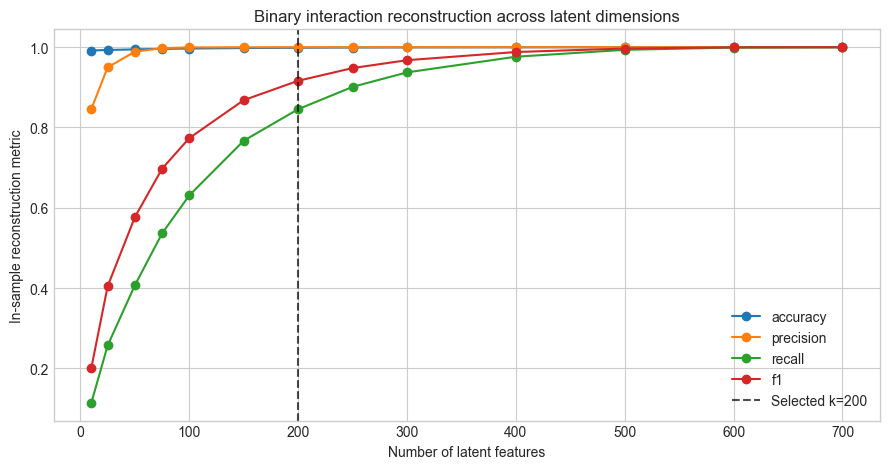

Cumulative explained variance at k=200: 82.29%
{'accuracy': 0.998586, 'precision': 1.0, 'recall': 0.845615, 'f1': 0.91635}


In [25]:
num_latent_feats = np.array([10, 25, 50, 75, 100, 150, 200, 250, 300, 400, 500, 600, 700])
truth = user_item.to_numpy(dtype=np.uint8)
running_estimate = np.zeros(user_item.shape, dtype=float)
metric_rows = []
previous_k = 0

for k_value in num_latent_feats:
    running_estimate += (
        u_sigma[:, previous_k:k_value] @ V_transpose[previous_k:k_value, :]
    )
    predicted = (np.abs(running_estimate) >= 0.5).astype(np.uint8)
    true_positive = int(np.logical_and(predicted == 1, truth == 1).sum())
    false_positive = int(np.logical_and(predicted == 1, truth == 0).sum())
    false_negative = int(np.logical_and(predicted == 0, truth == 1).sum())
    true_negative = int(np.logical_and(predicted == 0, truth == 0).sum())
    accuracy = (true_positive + true_negative) / truth.size
    precision = true_positive / max(true_positive + false_positive, 1)
    recall = true_positive / max(true_positive + false_negative, 1)
    f1 = 2 * precision * recall / max(precision + recall, np.finfo(float).eps)
    metric_rows.append(
        {"latent_features": k_value, "accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}
    )
    previous_k = k_value

reconstruction_metrics = pd.DataFrame(metric_rows).set_index("latent_features")
display(reconstruction_metrics.loc[[50, 100, 200, 300, 500, 700]].round(6))

ax = reconstruction_metrics.plot(figsize=(9, 4.8), marker="o")
ax.axvline(200, color="black", linestyle="--", alpha=0.7, label="Selected k=200")
ax.set(
    xlabel="Number of latent features",
    ylabel="In-sample reconstruction metric",
    title="Binary interaction reconstruction across latent dimensions",
)
ax.legend()
plt.tight_layout()
plt.show()

explained_variance_200 = float(svd.explained_variance_ratio_[:200].sum())
metrics_200 = reconstruction_metrics.loc[200]
print(f"Cumulative explained variance at k=200: {explained_variance_200:.2%}")
print(metrics_200.round(6).to_dict())


### Latent-feature decision

I select **200 latent features** as a practical compression point: it uses about 28% of
the original 714 article dimensions, explains roughly 82% of the decomposition variance,
and reconstructs observed interactions with approximately 1.00 precision and 0.846 recall.
Improvements continue with larger `k`, but they primarily memorize the training matrix.
Accuracy is especially optimistic because more than 99% of entries are zero. Thus 200 is
a transparent engineering trade-off and the dimension required for the downstream example,
not proof of optimal ranking quality. A held-out evaluation is still required.


In [26]:
def get_svd_similar_article_ids(
    article_id,
    vt,
    user_item=user_item,
    include_similarity=False,
):
    """Return article IDs ordered by cosine similarity in latent factor space."""
    article_id = int(article_id)
    if article_id not in user_item.columns:
        raise KeyError(f"Article {article_id} is not present in the user-item matrix.")
    if vt.ndim != 2 or vt.shape[1] != user_item.shape[1]:
        raise ValueError("vt must have one column per article in user_item.")

    article_idx = user_item.columns.get_loc(article_id)
    similarities = cosine_similarity(vt.T[[article_idx]], vt.T).ravel()
    article_ids = user_item.columns.to_numpy(dtype=int)
    order = np.lexsort((article_ids, -similarities))
    ordered_positions = [position for position in order if position != article_idx]
    most_similar_items = [int(article_ids[position]) for position in ordered_positions]
    if include_similarity:
        return [
            [int(article_ids[position]), float(similarities[position])]
            for position in ordered_positions
        ]
    return most_similar_items


In [27]:
k = 200
vt_new = V_transpose[:k, :]
expected_svd_recs = [1199, 1068, 486, 1202, 176, 1120, 244, 793, 58, 132]
rec_articles = get_svd_similar_article_ids(4, vt_new)[:10]

print("Seed article:", get_article_names([4])[0])
display(pd.DataFrame({"article_id": rec_articles, "title": get_article_names(rec_articles)}))
assert rec_articles == expected_svd_recs
assert set(rec_articles) == {1199, 1068, 486, 1202, 176, 1120, 244, 793, 58, 132}
assert get_svd_similar_article_ids(4, vt_new, include_similarity=True)[0][0] == 1199
print("SVD article-similarity tests: PASS")


Seed article: analyze ny restaurant data using spark in dsx


,article_id,title
0,1199,country statistics: crude oil - exports
1,1068,airbnb data for analytics: athens reviews
2,486,use spark r to load and analyze data
3,1202,country statistics: crude oil - proved reserves
4,176,top analytics tools in 2016
5,1120,airbnb data for analytics: paris calendar
6,244,notebooks: a power tool for data scientists
7,793,"10 powerful features on watson data platform, no coding necessary"
8,58,advancements in the spark community
9,132,collecting data science cheat sheets


SVD article-similarity tests: PASS


### Results, trade-offs, and an honest evaluation plan

The four methods solve different information regimes:

- **No history:** popularity is reliable and testable, but reinforces exposure bias.
- **Sparse history:** title content can provide topical relevance before enough neighbors
  exist, though short titles limit semantic fidelity.
- **Moderate history:** user-user filtering is explainable through similar readers, but can
  be expensive and unstable for sparse users.
- **Rich history:** SVD compresses co-consumption patterns efficiently, but latent neighbors
  are less interpretable and zeros are not true dislikes.

The reconstruction diagram is in-sample and cannot establish recommendation uplift. For an
offline experiment, split one interaction from every eligible user after deduplicating
user-article pairs; use chronological splits if timestamps become available. Refit all
popularity counts, user matrices, clusters, and factors on training data only. Compare
popularity, collaborative, content, SVD, and a history-length hybrid with Hit Rate@10,
Recall@10, MAP@10, NDCG@10, catalog coverage, novelty, and intra-list diversity, segmented
by user-history length. The central hypotheses are that popularity wins for zero-history
users, content helps sparse users, and collaborative/SVD models help active users.

In production, run a user-level A/B test against the popularity baseline. Primary outcomes
can include click-through, completion/dwell time, and saves; guardrails should include
bounce rate, catalog coverage, latency, and repeated exposure. This separates mathematical
reconstruction from actual reader value.


## Part VI: Deployment-Ready Facade

The thin class below reuses the rubric-tested functions rather than duplicating model logic.
Its small methods are suitable for a future web endpoint while keeping the notebook as the
single executable project artifact.


In [28]:
class IBMArticleRecommender:
    """Facade over popularity, collaborative, content, and latent recommenders."""

    def __init__(self, interactions, user_item_matrix, article_factors):
        """Store fitted data products required by the recommendation methods."""
        self.interactions = interactions
        self.user_item = user_item_matrix
        self.article_factors = article_factors

    def recommend_for_user(self, user_id, n=10):
        """Recommend for a known user or use popularity for an unknown user."""
        return user_user_recs_part2(
            user_id,
            m=n,
            user_item=self.user_item,
            df=self.interactions,
        )

    def recommend_similar_content(self, article_id, n=10):
        """Recommend articles from the seed article's fitted title cluster."""
        return make_content_recs(
            article_id,
            n,
            df=self.interactions,
            user_item=self.user_item,
        )

    def recommend_similar_latent(self, article_id, n=10):
        """Recommend articles with the closest reduced SVD factor vectors."""
        limit = _validate_recommendation_count(n)
        ids = get_svd_similar_article_ids(
            article_id,
            self.article_factors,
            user_item=self.user_item,
        )[:limit]
        return ids, get_article_names(ids, self.interactions)


recommender = IBMArticleRecommender(df, user_item, vt_new)
facade_new_ids, facade_new_titles = recommender.recommend_for_user(0, 5)
facade_known_ids, facade_known_titles = recommender.recommend_for_user(20, 5)

assert facade_new_ids == expected_top_10_ids[:5]
assert len(facade_new_ids) == len(facade_new_titles) == 5
assert len(facade_known_ids) == len(set(facade_known_ids)) == len(facade_known_titles) == 5
print("Deployment facade smoke tests: PASS")


Deployment facade smoke tests: PASS


## Conclusion

This project now provides deterministic rank, collaborative, content, and factorization
recommenders in one reproducible workflow. Popularity supplies a strong cold-start baseline;
cosine user similarity and activity-aware tie-breaking personalize known users; title
clusters create interpretable topical candidates; and 200-dimensional SVD factors expose
latent co-consumption relationships. The final validation below turns weak print-only helper
checks into explicit failing assertions and records a compact rubric status table.


In [29]:
known_user_recs, _ = recommender.recommend_for_user(20, 10)
final_checks = {
    "Part I contract": sol_1_dict == expected_sol_1,
    "ordered popularity IDs": get_top_article_ids(10) == expected_top_10_ids,
    "binary user-item shape": user_item.shape == (5149, 714),
    "user-item binary values": set(np.unique(user_item.to_numpy())) == {0, 1},
    "similar-user contract": sol_5_dict == expected_sol_5,
    "cold-start fallback": new_user_recs == expected_top_10_ids,
    "known-user unseen constraint": not set(known_user_recs).intersection(get_user_articles(20)[0]),
    "known-user no duplicates": len(known_user_recs) == len(set(known_user_recs)) == 10,
    "content source excluded": 25 not in rec_article_ids,
    "content rubric candidate": bool(expected_content_candidates.intersection(rec_article_ids)),
    "SVD article order": rec_articles == expected_svd_recs,
    "facade cold start": facade_new_ids == expected_top_10_ids[:5],
}
assert all(final_checks.values()), {name: passed for name, passed in final_checks.items() if not passed}

validation_table = pd.DataFrame(
    {"rubric_check": final_checks.keys(), "status": ["PASS" if value else "FAIL" for value in final_checks.values()]}
)
display(validation_table)
print(f"FINAL VALIDATION STATUS: ALL {len(final_checks)} CHECKS PASSED")


,rubric_check,status
0,Part I contract,PASS
1,ordered popularity IDs,PASS
2,binary user-item shape,PASS
3,user-item binary values,PASS
4,similar-user contract,PASS
5,cold-start fallback,PASS
6,known-user unseen constraint,PASS
7,known-user no duplicates,PASS
8,content source excluded,PASS
9,content rubric candidate,PASS


FINAL VALIDATION STATUS: ALL 12 CHECKS PASSED
